In [1]:
#vamos a abrir el archivo Activities-export_2-Feb-2026-21h.csv
# =========================================
# 0) Imports y setup
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
data_tossd = pd.read_csv("Activities-export_2-Feb-2026-21h.csv", low_memory=False)
data_tossd.head()


,Reporting year,Provider country/institution - code,Provider country/institution - name,Provider agency,Provider project number,TOSSD ID Number,TOSSD recipient - code,TOSSD recipient - name,Region,Project title,...,Reflows to the provider (USD thousand),Deflated reflows to the provider (USD thousand),Amount mobilised (USD thousand),Deflated amount mobilised (USD thousand),Salary cost (PPPs),Concessionality,Maturity (in months),Leveraging mechanism,Origin of the funds mobilised,Source name
0,2019,1057,UN Development Coordination Office,Non-core resources - TOSSD only,NaN,2019000024,434,Chile,South America,UN Resident Coordinator system,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,TOSSD
1,2019,1015,Development Bank of Latin America,Development Bank of Latin America,NaN,2019900012,434,Chile,South America,Aggregated disbursements,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,TOSSD
2,2020,431,Brazil,National Council for Scientific and Technologi...,190311/2017-7,2020000301,434,Chile,South America,Scholarships in Brasil (Masters),...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,TOSSD
3,2020,1057,UN Development Coordination Office,Non-core resources - TOSSD only,NaN,2020000024,434,Chile,South America,UN Resident Coordinator system,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,TOSSD
4,2020,932,Food and Agriculture Organisation,Voluntary earmarked contributions - global and...,PRJ_670861,2020002868,434,Chile,South America,NODO platform: Improving social protection and...,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,TOSSD


In [2]:
#vamos a averiguar las columnas del dataframe
data_tossd["Purpose name"].dropna().unique()


array(["Administration of developing countries' foreign aid",
       'Sectors not specified', 'Higher education', 'Social Protection',
       'Forestry development',
       'Forestry policy and administrative management',
       'Fishery education/training',
       'Food security policy and administrative management',
       'Basic life skills for adults',
       'Upper Secondary Education (modified and includes data from 11322)',
       'Primary education', 'Early childhood education',
       'Other prevention and treatment of NCDs',
       'Infectious disease control', 'COVID-19 control',
       'Health policy and administrative management', 'Basic health care',
       'Health personnel development', 'Tuberculosis control',
       'Basic nutrition', 'Promotion of mental health and well-being',
       'Medical services', 'Basic health infrastructure',
       'Population policy and administrative management',
       'National standards development', 'Elections',
       'Public sector p

In [3]:
# =========================================
# 2) Filtro: Biodiversity / Biosphere protection
#    OR SDG.focus contiene 15 y/o 14
# =========================================

# Asegurar strings para hacer contains con seguridad (NaN -> "")
sdg = data_tossd["SDG focus"].astype(str)
purpose = data_tossd["Purpose name"]

mask = (
    sdg.str.contains("15", na=False) |
    sdg.str.contains("14", na=False) |
    purpose.isin(["Biodiversity", "Biosphere protection"])
)

data_biodiversity = data_tossd.loc[mask].copy()

data_biodiversity.shape


(75, 53)

In [4]:
data_biodiversity.head()


,Reporting year,Provider country/institution - code,Provider country/institution - name,Provider agency,Provider project number,TOSSD ID Number,TOSSD recipient - code,TOSSD recipient - name,Region,Project title,...,Reflows to the provider (USD thousand),Deflated reflows to the provider (USD thousand),Amount mobilised (USD thousand),Deflated amount mobilised (USD thousand),Salary cost (PPPs),Concessionality,Maturity (in months),Leveraging mechanism,Origin of the funds mobilised,Source name
180,2021,940,International Labour Organisation,Regular Budget,63210-CHL151-Output 8.2,2021002513,434,Chile,South America,Contribution of 63210-DWT/CO-Santiago,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,TOSSD
299,2021,959,UNDP,Voluntary non-core funding,106962,2021004448,434,Chile,South America,6th National Reports in LAC II,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,TOSSD
300,2021,959,UNDP,Voluntary non-core funding,106038,2021004406,434,Chile,South America,Humboldt Fase 2,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,TOSSD
301,2021,959,UNDP,Voluntary non-core funding,88249,2021003937,434,Chile,South America,Ecorregion mediterranea,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,TOSSD
304,2021,959,UNDP,Voluntary non-core funding,117918,2021003342,434,Chile,South America,Fono Mayor,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,TOSSD


In [5]:
# =========================================
# 3) Ponderación:
#    - Amount.disbursed..USD.thousand. a numérico
#    - Weight = 1 si Purpose.name es Biodiversity o Biosphere protection
#              0.4 si SDG.focus contiene 15 o 14 (y no cae en el caso anterior)
#              0 en otro caso
#    - Weighted_Amount = Amount * Weight
# =========================================

amt_col = "Amount disbursed (USD thousand)"

data_biodiversity[amt_col] = pd.to_numeric(data_biodiversity[amt_col], errors="coerce")

is_purpose = data_biodiversity["Purpose name"].isin(["Biodiversity", "Biosphere protection"])
is_sdg = data_biodiversity["SDG focus"].astype(str).str.contains("15|14", na=False)

data_biodiversity["Weight"] = np.select(
    [is_purpose, is_sdg],
    [1.0, 0.4],
    default=0.0
)

data_biodiversity["Weighted_Amount"] = data_biodiversity[amt_col] * data_biodiversity["Weight"]

data_biodiversity[["Purpose name", "SDG focus", amt_col, "Weight", "Weighted_Amount"]].head()


,Purpose name,SDG focus,Amount disbursed (USD thousand),Weight,Weighted_Amount
180,Social Protection,17.18;17.14,71.00000,0.4,28.400000
299,Environmental policy and administrative manage...,15.9;15.5;15.2,0.09354,0.4,0.037416
300,Environmental policy and administrative manage...,15.2,15.25219,0.4,6.100876
301,Environmental policy and administrative manage...,15.2;15.1,158.00790,0.4,63.203160
304,Environmental policy and administrative manage...,15.2;15.1,283.89695,0.4,113.558780


In [6]:
#vamos a extportar este dataframe a un archivo csv
data_biodiversity.to_csv("data_biodiversity.csv", index=False)

In [7]:
# =========================================
# 4) Suma anual de Weighted_Amount por Reporting.year
# =========================================

# Asegurar que Reporting.year sea numérico (o al menos consistente)
data_biodiversity["Reporting year"] = pd.to_numeric(
    data_biodiversity["Reporting year"], errors="coerce"
)

data_biodiversity_sum = (
    data_biodiversity
    .groupby("Reporting year", dropna=False, as_index=False)
    .agg(Total_Amount=("Weighted_Amount", "sum"))
    .sort_values("Reporting year")
)

data_biodiversity_sum.head()


,Reporting year,Total_Amount
0,2021,2384.332904
1,2022,2758.553627
2,2023,5716.358046


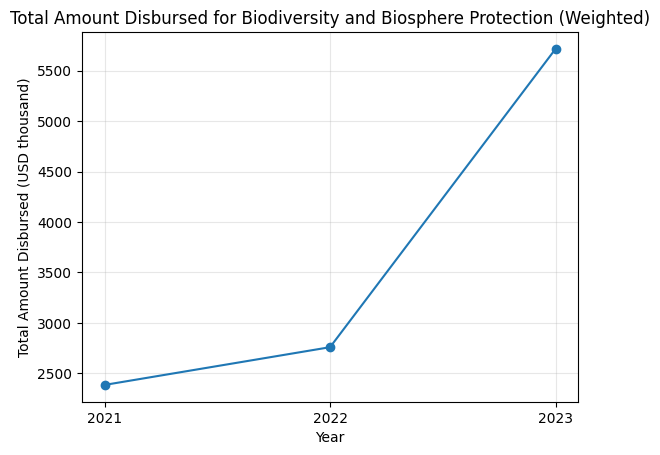

In [8]:
# =========================================
# 5) Plot línea/puntos con años enteros (2021–2023)
# =========================================
years = (
    data_biodiversity_sum["Reporting year"]
    .dropna()
    .astype(int)
    .unique()
)

plt.figure()

plt.plot(
    data_biodiversity_sum["Reporting year"],
    data_biodiversity_sum["Total_Amount"],
    marker="o"
)

plt.title("Total Amount Disbursed for Biodiversity and Biosphere Protection (Weighted)")
plt.xlabel("Year")
plt.ylabel("Total Amount Disbursed (USD thousand)")

# Forzar ticks solo a años enteros específicos
plt.xticks(sorted(years))

plt.grid(True, alpha=0.3)
plt.show()
